# Context-free grammar parsing with finite automata (using a Chomsky–Schützenberger representation)

PyFoma supports **exact CFG parsing** (and weighted CFG / PCFG-style parsing via costs) in the `cfg_parse` module.

The parser accepts arbitrary CFG grammars in the **same format** as `pyfoma.cfg`, and reuses `cfg.draw_tree()` for visualization.

In [1]:
from pyfoma import cfg, cfg_parse

## A first example

We will use the same grammar format as in `cfg.py`. The parser returns Penn Treebank style strings (PTB), and can also draw them with `cfg.draw_tree()`.

In [2]:
grammar = """
S -> a S b | a a S b | a S b b | EPSILON
"""

G = cfg_parse.CFGParse(grammar)
ptbs = G.parse_ptb("a a b b")
ptbs

['(S a (S a (S EPSILON) b) b)']

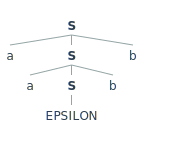

In [3]:
cfg.draw_tree(ptbs[0])

## Ambiguity

As with any CFG parser, an ambiguous sentence may have several parses.

A standard example is PP-attachment ambiguity.

In [4]:
grammar_pp = """
S  -> NP VP
NP -> D N | NP PP | N
VP -> V NP | V NP PP | V
PP -> P NP
D  -> a | the
N  -> man | boy | telescope
V  -> saw
P  -> with
"""

sent = "the man saw the boy with the telescope"

Gpp = cfg_parse.CFGParse(grammar_pp)
ptbs_pp = Gpp.parse_ptb(sent, n = 10)

len(ptbs_pp), ptbs_pp[:5]

(2,
 ['(S (NP (D the) (N man)) (VP (V saw) (NP (D the) (N boy)) (PP (P with) (NP (D the) (N telescope)))))',
  '(S (NP (D the) (N man)) (VP (V saw) (NP (NP (D the) (N boy)) (PP (P with) (NP (D the) (N telescope))))))'])

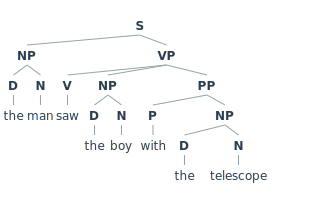

In [5]:
cfg.draw_tree(ptbs_pp[0])

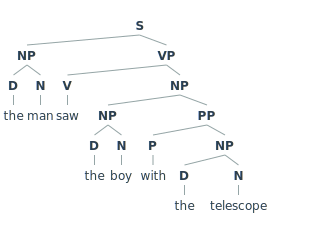

In [6]:
cfg.draw_tree(ptbs_pp[1])

## Weighted parsing (PCFG-style costs)

The parser supports **weights as additive costs** (lower is better). If you have a PCFG, convert rule probabilities to negative log-probabilities and use those as weights. Rules with no weights are treated as `0.0`.

In [7]:
grammar_pp_w = """
S  -> NP VP
NP -> D N | NP PP | N
VP -> V NP 1.0 | V NP PP 2.0 | V 3.0
PP -> P NP
D  -> a | the
N  -> man | boy | telescope
V  -> saw
P  -> with
"""

Gppw = cfg_parse.CFGParse(grammar_pp_w)

# Best parse(s), returned as (cost, ptb)
Gppw.parse_ptb_best(sent)

[(1.0,
  '(S (NP (D the) (N man)) (VP (V saw) (NP (NP (D the) (N boy)) (PP (P with) (NP (D the) (N telescope))))))')]

In [8]:
# n-best (wrapper over a lazy iterator)
Gppw.parse_ptb_nbest(sent, n = 5)

[(1.0,
  '(S (NP (D the) (N man)) (VP (V saw) (NP (NP (D the) (N boy)) (PP (P with) (NP (D the) (N telescope))))))'),
 (2.0,
  '(S (NP (D the) (N man)) (VP (V saw) (NP (D the) (N boy)) (PP (P with) (NP (D the) (N telescope)))))')]

In [9]:
# Lazy consumption
for cost, ptb in Gppw.iter_ptb_nbest(sent):
    print(cost, ptb)
    break

1.0 (S (NP (D the) (N man)) (VP (V saw) (NP (NP (D the) (N boy)) (PP (P with) (NP (D the) (N telescope))))))


## How the parser works

## Dense version

- We work with **bracketed string representations of parse trees**, and compile the CFG into an FSA (the local grammar) that accepts all **locally correct** bracketings.
- To parse an input string $w$, we build an FSA that accepts exactly the strings obtained by inserting arbitrary typed brackets anywhere in $w$ (while keeping the terminals of $w$ in order).
- We intersect that sentence FSA with the local-grammar FSA.
- From the result, we extract exactly those strings whose typed brackets are **properly balanced** (matched and nested).

## Long version

Before talking about the implementation details, it helps to recall the underlying idea from the Chomsky–Schützenberger theorem.

### The Chomsky–Schützenberger viewpoint

A classic [theorem by Chomsky and Schützenberger](https://en.wikipedia.org/wiki/Chomsky%E2%80%93Sch%C3%BCtzenberger_representation_theorem) (1963) says (informally) that **every context-free language can be described using only two ingredients**:

1. a language of **balanced parentheses** (a [Dyck language](https://en.wikipedia.org/wiki/Dyck_language)), and  
2. a **regular language** that filters which parenthesis/terminal strings are "locally well-formed."

More precisely: a context-free language can be obtained as a homomorphic image of the intersection of a Dyck language (balanced brackets) with a suitable regular language. The important intuition is:

> Context-freeness comes from *matching and nesting* (balanced brackets),  
> while the grammar-specific constraints can be enforced *locally* (regularly).

A tiny mental model:

- The Dyck language guarantees that brackets are properly nested, e.g.
  `(()())` is fine, `(()` and `())(` are not.
- A regular language can enforce local constraints like:
  "after this opening bracket, you may only see a terminal or another opening bracket of certain types,"
  "after closing a position, you must open the next position," etc.

For a proof of the theorem that's not unnecessarily complicated, see [Kozen (1997)](https://vishub.org/officedocs/13770.pdf).

### A concrete example

Suppose we have the grammar:

- $r_1: S \to SS$
- $r_2: S \to a$

A parse tree like:

$$
\texttt{(S (S a) (S a))}
$$

can be encoded as a string that mixes terminals with *typed brackets* (brackets that remember which rule and which RHS position they belong to). If we erase the bracket symbols, we get the yield `aa`. If we keep them, we get a well-bracketed structure that corresponds to the tree.

At this point, parsing can be viewed as:

1. generate all strings over terminals + typed brackets that are **locally consistent** with the grammar (regular constraints), and
2. keep only those strings where the brackets are **globally well-nested** (Dyck-style balance),
3. then erase the brackets (or decode them) to recover the parse tree / yield.

That is exactly what the implementation does.


### How the parser instantiates this idea

What the parser does is a sentence-specific version of the C–S recipe:

> First, we compile the CFG into a **regular local grammar** over terminals plus typed bracket symbols.  
> Then, for a given input string $w$, we build an automaton that accepts exactly all strings obtained by inserting arbitrary brackets into $w$ (while keeping the terminals in order).  
> We intersect these two automata.  
> The result contains **all candidate parses of $w$** in bracketed-string form — plus some extra strings that are locally legal but whose brackets are not globally well-balanced.  
> Finally, we extract exactly those strings whose typed brackets are properly balanced; those are the parses.

In notation, the sentence-specific automaton is:

$$
R^{local} = R \cap h^{-1}(w)
$$

where:

- $R$ is the regular language enforcing **local CFG legality**, and
- $h^{-1}(w)$ is the language of all terminal+bracket strings whose terminal projection is exactly $w$.

The last step (`extractbalanced`) removes the false positives that remain because local constraints alone do not enforce global nesting.

This notebook follows the notation and examples from Hulden (2009) closely.

## C-S encoding of a parse tree (paper notation)

Suppose a grammar has a rule

$$
A \rightarrow \alpha
$$

where $|\alpha| = n$. For this rule we introduce **2n bracket symbols**:

- opening brackets:

$$
(_{A \rightarrow \alpha}^{1}, \ldots, (_{A \rightarrow \alpha}^{n}
$$

- closing brackets:

$$
)_{A \rightarrow \alpha}^{1}, \ldots, )_{A \rightarrow \alpha}^{n}
$$

Each bracket pair corresponds to a **position** on the RHS of the rule.

### Small example

If the grammar contains

$$
A \rightarrow BC,\quad B \rightarrow x,\quad C \rightarrow y
$$

then for the rule $A \rightarrow BC$ we get four bracket symbols:

- $(_{A \rightarrow BC}^{1}$, $)_{A \rightarrow BC}^{1}$
- $(_{A \rightarrow BC}^{2}$, $)_{A \rightarrow BC}^{2}$

(and similarly for the unary rules $B \to x$, $C \to y$).

The tree

$$
\texttt{(A (B x) (C y))}
$$

is encoded as

$$
(_{A \rightarrow BC}^{1}~
(_{B \rightarrow x}^{1}~ x~ )_{B \rightarrow x}^{1}~
)_{A \rightarrow BC}^{1}~
(_{A \rightarrow BC}^{2}~
(_{C \rightarrow y}^{1}~ y~ )_{C \rightarrow y}^{1}~
)_{A \rightarrow BC}^{2}
$$

If we erase the bracket symbols, we get the terminal yield $xy$.

### Concrete tree example (repeated `S` nodes)

Consider the parse tree

$$
\texttt{(S (S a) (S (S a) (S a)))}
$$

and assume the grammar has rules:

- $r_1: S \to SS$
- $r_2: S \to a$

Then we have bracket symbols:

- for $r_1$:
  - $(_{r_1}^{1}, )_{r_1}^{1}$
  - $(_{r_1}^{2}, )_{r_1}^{2}$
- for $r_2$:
  - $(_{r_2}^{1}, )_{r_2}^{1}$

A paper-style encoding of the tree is:

$$
\begin{aligned}
&(_{r_1}^{1}
  (_{r_2}^{1}\ a\ )_{r_2}^{1}
 )_{r_1}^{1}\\
&(_{r_1}^{2}
  (_{r_1}^{1}
    (_{r_2}^{1}\ a\ )_{r_2}^{1}
  )_{r_1}^{1}
  (_{r_1}^{2}
    (_{r_2}^{1}\ a\ )_{r_2}^{1}
  )_{r_1}^{2}
 )_{r_1}^{2}
\end{aligned}
$$

Erasing the brackets yields `aaa`.

This is the key move: a parse tree becomes a **string**, and parsing becomes recognizing the right subset of such strings.

## The regular language $R$

Let $\Sigma_T$ be the set of terminals and $\Sigma_{()}$ the set of all typed bracket symbols.

The local parser automaton is built over

$$
\Sigma = \Sigma_T \cup \Sigma_{()}
$$

and accepts strings that satisfy a collection of **strictly local constraints**.

These constraints are exactly what the paper packages as conditions (a)–(e).

### Local successor notation

The paper uses notation of the form

$$
x \rightsquigarrow Y
$$

to mean:

> every occurrence of symbol $x$ is immediately followed by a symbol from the set $Y$.

This is a local condition, so it is regular.

### Conditions (a)–(e)

(For readers comparing this list directly with Hulden (2009), note that the presentation here makes a few small implementation-oriented changes: some cases are regrouped/reordered for clarity, and we add explicit handling of `EPSILON` and end-of-string legality.)

Write a rule as

$$
A \rightarrow B_1 \ldots B_n
$$

where each $B_i$ is either a terminal or a nonterminal.

For each rule-position $(A \to B_1\ldots B_n, i)$, the parser introduces a typed bracket pair. In the code these appear as symbols like:

- `OB__rid__i` (opening bracket for rule `rid`, position `i`)
- `CB__rid__i` (closing bracket for rule `rid`, position `i`)

For readability below, we will write these as `OB(r,i)` and `CB(r,i)`.

The local constraints enforced by $R$ are:

**(a) Boundary legality**

- Start of string: only opening brackets of rules expanding the start symbol are allowed.
- End of string: only final closing brackets of start-symbol rules are allowed.

For example, if the start symbol is `S` and one rule is

$$
r_7:\ S \to NP\ VP
$$

then a valid encoded parse string may begin with `OB(r7,1)` (the first RHS position of an `S`-rule), but it should not begin with something like `OB(r12,1)` if `r12` expands `NP` rather than `S`.

Likewise, a valid complete parse for that rule may end in `CB(r7,2)` (the final position of `S \to NP\ VP`), but not in `CB(r7,1)` (which closes only the first child position).

In code this is represented by:

- `allowed_starts`
- `allowed_finals`

**(b) What may follow an opening bracket** `OB(r,i)`

Suppose rule `r` is

$$
A \to B_1 \ldots B_n
$$

and we are looking at `OB(r,i)`.

- If $B_i$ is a **nonterminal**, then the next symbol must be the first opening bracket of some rule expanding $B_i$.
- If $B_i$ is a **terminal**, then the next symbol must be that terminal.
- If $B_i = \text{EPSILON}$, then the next symbol may be the matching closing bracket `CB(r,i)`.

Examples:

- **Nonterminal case.**  
  If
  $$
  r_7:\ S \to NP\ VP
  $$
  then after `OB(r7,1)` (the `NP` position), the next symbol must be the first opening bracket of some `NP` rule, e.g. `OB(r12,1)` if
  $$
  r_{12}:\ NP \to D\ N
  $$
  or `OB(r13,1)` if
  $$
  r_{13}:\ NP \to N.
  $$

- **Terminal case.**  
  If
  $$
  r_{20}:\ D \to \text{the}
  $$
  then after `OB(r20,1)` the next symbol must be the terminal `the`.

- **EPSILON case.**  
  If
  $$
  r_{30}:\ T \to \text{EPSILON}
  $$
  then after `OB(r30,1)` the next symbol may immediately be `CB(r30,1)`, since there is no terminal/nonterminal child content to encode at that position.

**(c) What may follow a terminal**

A terminal may be followed by a closing bracket corresponding to a rule-position that emits that terminal.

For example, if

$$
r_{20}:\ D \to \text{the}
$$

then the local pattern

```text
OB(r20,1)  the  CB(r20,1)
```

is allowed, so after the terminal `the`, the next symbol may be `CB(r20,1)`.

Similarly, if

$$
r_{21}:\ N \to \text{boy}
$$

then after the terminal `boy`, the next symbol may be `CB(r21,1)`.

This condition is what lets terminal emissions “return” to the enclosing rule-position structure.

**(d) What may follow a non-final closing bracket**

If we close position $i<n$ of a rule application, the next symbol must be the opening bracket for position $i+1$ of the same rule.

For example, if

$$
r_7:\ S \to NP\ VP
$$

then after `CB(r7,1)` (closing the `NP` position), the next symbol must be `OB(r7,2)` (opening the `VP` position).

Likewise, if

$$
r_{12}:\ NP \to D\ N
$$

then after `CB(r12,1)` the next symbol must be `OB(r12,2)`.

This enforces the left-to-right order of RHS positions inside a rule application.

**(e) What may follow a final closing bracket**

After the last position of a rule is closed, the next symbol may be:

* another closing bracket (continuing the return to an enclosing constituent), and/or
* end-of-string (if this also satisfies boundary condition (a)).

For example, if

$$
r_{12}:\ NP \to D\ N
$$

then after `CB(r12,2)` (the final position of that `NP` rule), the next symbol might be:

* `CB(r7,1)` if that `NP` was the first child of an enclosing
  $$
  r_7:\ S \to NP\ VP
  $$
  and we are now returning to close the `NP` position of `S`; or
* end-of-string, in the special case where this rule application also completes the full parse and the symbol is in `allowed_finals`.

In code, the local successor relation for these conditions is stored in:

* `next_map[sym]`

### Two ways of building `R`

The module supports two interchangeable backends:

- `local_builder="direct"`  
  Builds the FST graph directly from `allowed_starts`, `allowed_finals`, and `next_map`.

- `local_builder="regex"`  
  Builds the same local language with `FST.re(...)` and `$^restrict(...)`, which is often a more readable way to express conditions (a)–(e).

---

## The sentence language $h^{-1}(w)$

For an input sentence $w = t_1 \ldots t_n$, we need all encoded strings whose terminal projection is exactly $w$.

That language is $h^{-1}(w)$: bracket symbols may appear anywhere, but terminals must appear **exactly in order**.

### Direct construction intuition

The direct builder creates an automaton with $n+1$ states:

- one terminal edge for each token position
- bracket self-loops at every state

### Regex view

The same language can be described as

$$
B^*\, t_1\, B^*\, t_2\, \cdots\, t_n\, B^*
$$

where $B$ is the union of all bracket symbols.

## The local parse automaton $R^{local}$

We now intersect the local language and the sentence language:

$$
R^{local} = R \cap h^{-1}(w)
$$

This automaton accepts exactly those strings that are:

- locally legal with respect to the grammar (conditions (a)–(e))
- terminal-compatible with the input sentence

But it may still contain strings whose brackets are not properly nested or matched.

That remaining condition is handled by **balanced extraction**.

## Balanced extraction (`extractbalanced`)

After we build

$$
R^{local} = R \cap h^{-1}(w)
$$

the remaining task is:

> Extract from the resulting FSA all and only those strings whose brackets are balanced.

This is exactly what the `extractbalanced` step does.

### A generic viewpoint

It is helpful to see `extractbalanced` as a **generic algorithm**:

- **Input:** an FSA over some alphabet that includes designated opening and closing bracket symbols
- **Output:** the subset of accepted strings in which the brackets are properly balanced (and, in our parser, properly typed/matched)

In other words, `extractbalanced` is not tied specifically to CFG parsing.

In this parser we apply it to $R^{local}$, where the regular-language stage has already enforced local grammatical constraints.

That division of labor is the whole point:

- $R$ handles **local grammatical legality**
- $h^{-1}(w)$ handles **the input sentence**, inserting brackets into it
- `extractbalanced` handles **global nesting and matching**

### State pairs as spans

The implementation realizes extraction as a dynamic program over **pairs of automaton states** $(p,q)$.

Intuition:

> $(p,q)$ means there is a path from state `p` to state `q` whose brackets are balanced (typed and properly nested).

This is very similar in spirit to chart parsing spans, except that the "span endpoints" are automaton states rather than token indices.

### Seed pairs

The algorithm starts from:

- **empty pairs** $(s,s)$
- **terminal pairs** $(p,q)$ where there is a terminal transition $p \xrightarrow{t} q$

### Closure operations

The algorithm repeatedly adds balanced pairs using two operations:

**1) Concatenation**

If $(p,q)$ and $(q,r)$ are balanced fragments, then $(p,r)$ is balanced.

**2) Wrap**

If a balanced fragment can be surrounded by a matching typed opening/closing bracket pair (same rule id and RHS position), then the larger fragment is balanced.

In symbols, this corresponds to building pieces of the form

$$
(_r^i \ \cdots\ )_r^i
$$

around an already balanced inner path.

### Why this is enough

Because `R` already enforces all local CFG legality conditions, balanced extraction does **not** need to check those again.

It mostly needs:

- state connectivity (for concatenation)
- exact typed bracket matching (for wrap)

This is what makes the two-stage construction simple.

## Decoding to PTB

Once a balanced encoded string is reconstructed, the parser decodes it into PTB format.

The current decoder walks the encoding recursively:

- `OB(rid,1)` starts a constituent and identifies the rule
- RHS positions are processed in order
- terminals are emitted directly
- nonterminals recurse
- matching `CB(rid,i)` closes each position

The result is a Penn Treebank style string that can be drawn with `cfg.draw_tree()`.

## Best parse and n-best

### `parse_ptb_best(...)`

The weighted best parser uses a heap-based balanced extraction and keeps the best cost found for each state pair $(p,q)$.

Costs compose additively through:

- terminal traversals (usually zero)
- concatenation
- wrap operations
- rule costs attached to `OB(rid,1)`

This behaves like a shortest-path / dynamic-programming computation over the balanced-pair search space.

### `iter_ptb_nbest(...)`

The current n-best interface is a **lazy output interface**:

- it yields parses in increasing cost order
- the caller can stop whenever enough parses have been seen

## Running time (once the grammar is compiled)

Once the grammar-local automaton `R` is compiled, parsing a sentence mainly consists of:

1. building $h^{-1}(w)$
2. intersecting to form $R^{local}$
3. balanced extraction
4. decoding

For a **fixed compiled grammar**, a good mental model is:

- $h^{-1}(w)$: linear in sentence length
- intersection and trim: linear in sentence length (grammar-dependent constants)
- balanced extraction: the dominant term, cubic in sentence length
- decoding one parse: linear in tree size

So best parsing behaves much like classical chart parsing in asymptotic growth, even though the implementation route is quite different. However, this algorithm requires no special treatment of long CFG rules (like CKY does), or unary rules, or epsilons. Arbitrary CFG rules are allowed, and parsing proceeds by intersecting $R$ with $h^{-1}(w)$ to obtain $R^{local}$, followed by balanced-bracket extraction.

## Direct vs regex builders

The module ships with direct and regex builders for both pedagogical and practical reasons.

### `direct`

- fastest in practice
- explicit transition-level construction
- excellent default

### `regex`

- compact and close to paper notation
- nice for inspection / cross-checking
- useful for understanding how (a)–(e) become regular constraints

In [10]:
G_direct = cfg_parse.CFGParse(grammar_pp_w, local_builder="direct", sent_builder="direct")
G_regex = cfg_parse.CFGParse(grammar_pp_w, local_builder="regex", sent_builder="regex")

print(G_direct.show_symbols())
print(G_direct.debug_local_stats(sent))
print(G_regex.debug_local_stats(sent))

{'start_symbol': 'S', 'nonterminals': ['D', 'N', 'NP', 'P', 'PP', 'S', 'V', 'VP'], 'surface_terminals': ['the', 'with', 'man', 'telescope', 'saw', 'boy', 'a'], 'num_rules': 15, 'num_brackets': 44, 'allowed_starts': ['OB__0__1'], 'allowed_finals': ['CB__0__2'], 'local_builder': 'direct', 'sent_builder': 'direct'}
{'sentence': 'the man saw the boy with the telescope', 'states': 196, 'transitions': 2215, 'finalstates': 1, 'alphabet_size': 51}
{'sentence': 'the man saw the boy with the telescope', 'states': 70, 'transitions': 344, 'finalstates': 1, 'alphabet_size': 51}


## Debugging / introspection helpers

The module includes a few helpers that are useful during development and benchmarking.

In [11]:
# G is:
# S -> a S b | a a S b | a S b b | EPSILON
G.show_symbols()

{'start_symbol': 'S',
 'nonterminals': ['S'],
 'surface_terminals': ['a', 'b'],
 'num_rules': 4,
 'num_brackets': 24,
 'allowed_starts': ['OB__0__1', 'OB__1__1', 'OB__2__1', 'OB__3__1'],
 'allowed_finals': ['CB__0__3', 'CB__1__4', 'CB__2__4', 'CB__3__1'],
 'local_builder': 'direct',
 'sent_builder': 'direct'}

In [12]:
G.debug_local_stats("a a a b b b")

{'sentence': 'a a a b b b',
 'states': 123,
 'transitions': 397,
 'finalstates': 4,
 'alphabet_size': 26}

In [13]:
G.show_R_regex_recipe()

'R = $START $SYM* $FINAL  & successor $^restrict(...) clauses per symbol for (b)-(e)  ; then apply weights on OB(rid,1) transitions'

In [14]:
# Size of R, the local grammar
len(G.R)

27

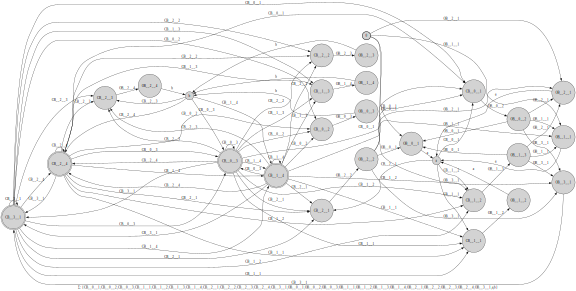

In [15]:
G.R.view()

## Example (a highly ambiguous grammar)

In [16]:
grammar_ratio = """
S -> a S b | a a S b | a S b b | EPSILON
"""

Gr = cfg_parse.CFGParse(grammar_ratio)
print(Gr.show_symbols())
print(Gr.debug_local_stats("a a a a a b b b b b"))

parses = Gr.parse_ptb("a a a a a b b b b b", n=20)
for p in parses:
    print(p)

{'start_symbol': 'S', 'nonterminals': ['S'], 'surface_terminals': ['a', 'b'], 'num_rules': 4, 'num_brackets': 24, 'allowed_starts': ['OB__0__1', 'OB__1__1', 'OB__2__1', 'OB__3__1'], 'allowed_finals': ['CB__0__3', 'CB__1__4', 'CB__2__4', 'CB__3__1'], 'local_builder': 'direct', 'sent_builder': 'direct'}
{'sentence': 'a a a a a b b b b b', 'states': 197, 'transitions': 637, 'finalstates': 4, 'alphabet_size': 26}
(S a (S a (S a a (S a (S EPSILON) b b) b) b) b)
(S a (S a (S a (S a a (S EPSILON) b) b b) b) b)
(S a (S a (S a (S a (S a (S EPSILON) b) b) b) b) b)
(S a (S a a (S a (S a (S EPSILON) b b) b) b) b)
(S a (S a a (S a (S a (S EPSILON) b) b b) b) b)
(S a (S a (S a (S a a (S EPSILON) b) b) b b) b)
(S a (S a (S a a (S a (S EPSILON) b) b) b b) b)
(S a (S a (S a (S a a (S EPSILON) b) b) b) b b)
(S a (S a (S a a (S a (S EPSILON) b) b) b) b b)
(S a (S a a (S a (S a (S EPSILON) b) b) b) b b)
(S a a (S a (S a (S a (S EPSILON) b b) b) b) b)
(S a a (S a (S a (S a (S EPSILON) b) b b) b) b)
(S a a 

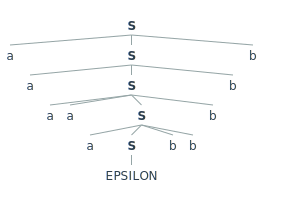

In [17]:
cfg.draw_tree(parses[0])

In [18]:
grammar_ratio_w = """
S -> a S b 1.0 | a a S b 2.0 | a S b b 3.0 | EPSILON 0.5
"""

Grw = cfg_parse.CFGParse(grammar_ratio_w)
print("Best:", Grw.parse_ptb_best("a a a a a b b b b b"))
print("N-best:", Grw.parse_ptb_nbest("a a a a a b b b b b", n=5))

Best: [(5.5, '(S a (S a (S a (S a (S a (S EPSILON) b) b) b) b) b)'), (7.5, '(S a (S a a (S a (S a (S EPSILON) b) b) b) b b)'), (7.5, '(S a a (S a (S a (S a (S EPSILON) b) b) b b) b)')]
N-best: [(5.5, '(S a (S a (S a (S a (S a (S EPSILON) b) b) b) b) b)'), (7.5, '(S a (S a a (S a (S a (S EPSILON) b) b b) b) b)'), (7.5, '(S a (S a a (S a (S a (S EPSILON) b b) b) b) b)'), (7.5, '(S a (S a (S a a (S a (S EPSILON) b) b) b b) b)'), (7.5, '(S a (S a (S a (S a a (S EPSILON) b) b) b b) b)')]


## A note on grammar format

`cfg_parse.CFGParse(...)` intentionally reuses `pyfoma.cfg.parse_cfg()` so that grammars can be shared between:

- `pyfoma.cfg` (approximation and utilities)
- `cfg_parse` (exact parsing)

This also makes it natural to reuse `cfg.draw_tree()` for visualization.

## Extensions

Others have extended the idea in Hulden(2009) - e.g. Denkinger (2016) implements Weighted Multiple Context-Free Grammars with a similar method; Ruprecht (2018) builds a parser for such representations. These are not implemented here, but contributions are welcome!

## References

Chomsky, Noam. (1962). Context-Free Grammars and Pushdown Storage. Tech. Rep., MIT Research Lab in Electronics. Cambridge, MA. [[PDF](https://dspace.mit.edu/bitstream/handle/1721.1/53697/RLE_QPR_065_XVII.pdf?sequence=1&isAllowed=y)]


Chomsky, Noam and Marcel-Paul Schützenberger. (1963). The algebraic theory of context-free languages.
In: Braffort, P., Hirschberg, D. (eds.) Computer Programming and Formal Systems,
pp. 118–161. North Holland, Amsterdam. [[PDF](http://www-igm.univ-mlv.fr/~berstel/Mps/Travaux/A/1963-7ChomskyAlgebraic.pdf)]

Denkinger, T. (2016). *A Chomsky-Schützenberger Representation for Weighted Multiple Context-free Languages*. ArXiv, abs/1606.03982. [[PDF](https://www.semanticscholar.org/reader/3ac7b41e8ecda2ab4b7effc8cd81d51c7d5a3fa3)]

Hulden, Mans. (2009). *Parsing CFGs and PCFGs with a Chomsky-Schützenberger representation*. In Language and Technology Conference (pp. 151-160). Berlin, Heidelberg: Springer Berlin Heidelberg. [[PDF](https://verbs.colorado.edu/~mahu0110/pubs/Parsing%20CFGs%20and%20PCFGs%20with%20a%20Chomsky-Schu%CC%88tzenberger%20Representation%20(Hulden,%202011).pdf)]

Hulden, Mans and Miikka Silfverberg. *Finite-state subset approximation of phrase structure*. In International Symposium on Artificial Intelligence and Mathematics (ISAIM 2014), Fort Lauderdale, FL, USA, January 6-8, 2014. [[PDF]](https://web.archive.org/web/20210422143250id_/https://www.cs.uic.edu/pub/Isaim2014/WebPreferences/ISAIM2014_NLP_Hulden_Silfverberg.pdf)

Ruprecht, T. (2018). *Master Defense: Implementation and evaluation of k-best Chomsky-Schützenberger parsing for weighted multiple context-free grammars*. [[PDF of slides](https://www.orchid.inf.tu-dresden.de/assets/unrestricted/Freitagsseminar-2018-03-21-Slides.pdf)]